# **Module 2: Distributions**

This notebook covers the fundamentals of Random Variables, the most common probability distributions, and the introduction to the Generation of Pseudorandom Numbers (PRNG), as per the curriculum plan.

## **I. Introduction and Fundamentals**

### **1. Concept of Random Variable (R.V.) and State Space**

A **Random Variable ($X$)** is a function that assigns a numerical value to each possible outcome of a random experiment.

- **Sample Space ($\Omega$)**: The set of all possible outcomes of an experiment.
- **Random Variable ($X$)**: A function $X: \Omega \to \mathbb{R}$.

Random variables can be classified into:

- **Discrete**: Assume a countable set of values (e.g., number of lost packets in a network transmission).
- **Continuous**: Assume any value within an interval (e.g., temperature measured by a sensor, battery lifespan).

### **2. Probability Density Function (PDF) and Probability Mass Function (PMF)**

**Probability Mass Function (PMF)** - For Discrete Random Variables:

The probability of $X$ taking a specific value $x$ is given by $P(X=x) = p(x)$.

$$\sum_{x} p(x) = 1$$

**Probability Density Function (PDF)** - For Continuous Random Variables:

The probability of $X$ being in an interval $[a, b]$ is given by the integral of the density function $f(x)$.

$$P(a \le X \le b) = \int_{a}^{b} f(x) dx$$

Note that $P(X=x) = 0$ for any point $x$ in a Continuous R.V. What matters is the area under the curve.

$$\int_{-\infty}^{\infty} f(x) dx = 1$$

---

## **II. Common Distributions**

We will explore the most relevant distributions for Data Science, using **Python** to simulate sensor data and visualize their behavior.

### **1. Continuous R.V.: Normal and Uniform Distribution**

Primeiro, vamos importar as bibliotecas essenciais:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, uniform

**Continuous Uniform Distribution**

Represents an experiment where all outcomes in an interval $[a, b]$ are equally likely.

- **Example:** Simulation of a light level sensor that operates perfectly between 0 and 100 lux.

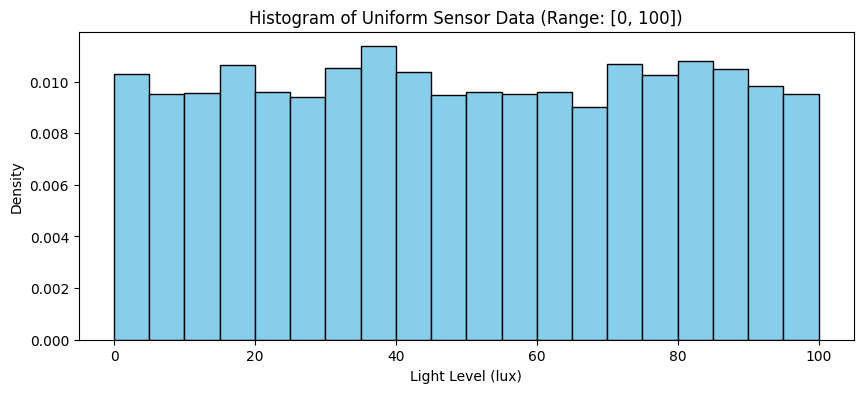

In [2]:
# Uniform Distribution Parameters
a = 0  # Lower limit (min 0 lux)
b = 100 # Upper limit (max 100 lux)
num_samples = 5000

# Generation of simulated light level data
data_uniform = uniform.rvs(loc=a, scale=b-a, size=num_samples)

# Visualization of the distribution
plt.figure(figsize=(10, 4))
plt.hist(data_uniform, bins=20, density=True, color='skyblue', edgecolor='black')
plt.title(f'Histogram of Uniform Sensor Data (Range: [{a}, {b}])')
plt.xlabel('Light Level (lux)')
plt.ylabel('Density')
plt.show()

**Normal (Gaussian) Distribution**

The most important distribution in statistics, described by two parameters: the mean ($\mu$) and the standard deviation ($\sigma$).

$$f(x) = \frac{1}{\sigma \sqrt{2\pi}} e^{-\frac{1}{2}\left(\frac{x - \mu}{\sigma}\right)^2}$$

- **Example:** Simulation of temperature measurements.

<>:19: SyntaxWarning: invalid escape sequence '\m'
<>:19: SyntaxWarning: invalid escape sequence '\s'
<>:19: SyntaxWarning: invalid escape sequence '\m'
<>:19: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_235/2184089603.py:19: SyntaxWarning: invalid escape sequence '\m'
  plt.title(f'Temperature Distribution (Normal: $\mu={mu}$, $\sigma={sigma}$)')
/tmp/ipykernel_235/2184089603.py:19: SyntaxWarning: invalid escape sequence '\s'
  plt.title(f'Temperature Distribution (Normal: $\mu={mu}$, $\sigma={sigma}$)')


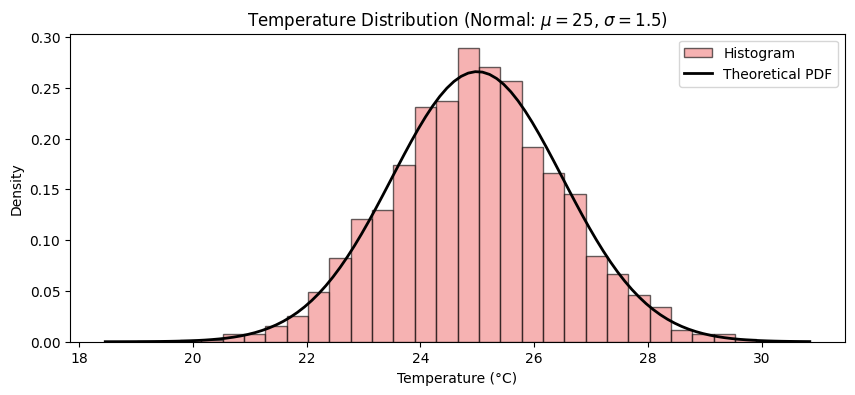

In [3]:
# Normal Distribution Parameters
mu = 25    # Mean (Temperature in °C)
sigma = 1.5 # Standard Deviation
num_samples = 5000

# Generation of simulated temperature data
data_normal = norm.rvs(loc=mu, scale=sigma, size=num_samples)

# Visualization
plt.figure(figsize=(10, 4))
plt.hist(data_normal, bins=30, density=True, color='lightcoral', edgecolor='black', alpha=0.6, label='Histogram')

# Plot of the theoretical PDF
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, sigma)
plt.plot(x, p, 'k', linewidth=2, label='Theoretical PDF')

plt.title(f'Temperature Distribution (Normal: $\mu={mu}$, $\sigma={sigma}$)')
plt.xlabel('Temperature (°C)')
plt.ylabel('Density')
plt.legend()
plt.show()

### **2. Discrete R.V.: Bernoulli and Binomial Distribution**

**Bernoulli Distribution**

Describes an experiment with only two possible outcomes: success (probability $p$) or failure ($1-p$).

- $P(X=1) = p$
- $P(X=0) = 1-p$

In [5]:
from scipy.stats import bernoulli

p_success = 0.8 # 80% chance of detecting presence
num_trials = 1000
data_bernoulli = bernoulli.rvs(p=p_success, size=num_trials)

successes = np.sum(data_bernoulli == 1)
failures = np.sum(data_bernoulli == 0)

print(f"Successes: {successes}, Failures: {failures}")

Successes: 796, Failures: 204


### **3. Marginal and Conditional Distributions**

When dealing with multiple random variables, we often look at their individual (marginal) or dependent (conditional) behaviors.

**Marginal Probability Density:**
If we have a joint PDF $f(x, y)$, the marginal density of $X$ is:
$$f_X(x) = \int_{-\infty}^{\infty} f(x, y) dy$$

**Conditional Probability Density:**
The density of $X$ given that $Y=y$ has occurred:
$$f_{X|Y}(x|y) = \frac{f(x, y)}{f_Y(y)}, \quad f_Y(y) > 0$$

- **Example:** In sensor fusion, we might want to know the probability of a temperature reading ($X$) given a specific humidity level ($Y$).

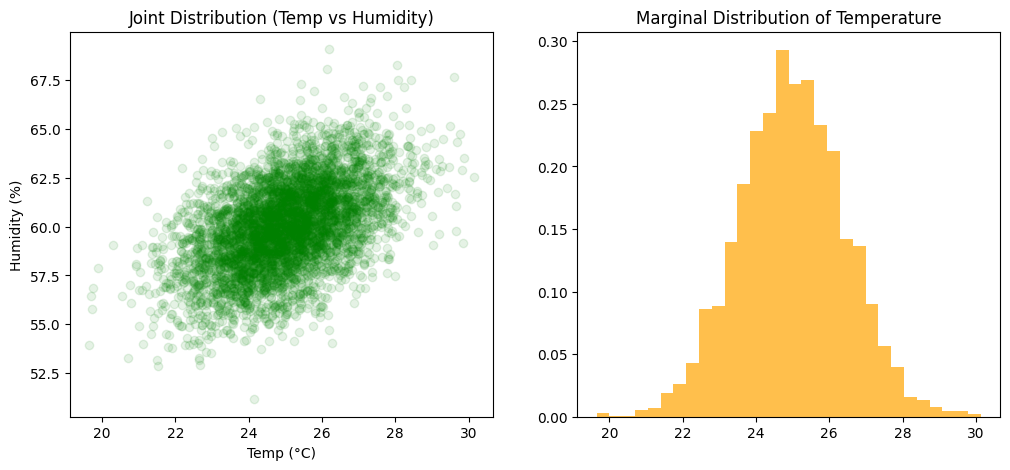

In [6]:
# Simulating Joint, Marginal and Conditional distribution
# Let's assume X (Temperature) and Y (Humidity) are correlated
mean = [25, 60]  # Means for Temp and Humidity
cov = [[2, 1.5], [1.5, 5]]  # Covariance matrix

data = np.random.multivariate_normal(mean, cov, 5000)
temp, humidity = data[:, 0], data[:, 1]

# Visualization
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(temp, humidity, alpha=0.1, color='green')
plt.title('Joint Distribution (Temp vs Humidity)')
plt.xlabel('Temp (°C)')
plt.ylabel('Humidity (%)')

plt.subplot(1, 2, 2)
plt.hist(temp, bins=30, density=True, color='orange', alpha=0.7)
plt.title('Marginal Distribution of Temperature')
plt.show()

## **III. Generation of Pseudorandom Numbers (PRNG)**

To simulate stochastic systems, we need methods to generate numbers that follow specific distributions.

### **1. Uniform Pseudorandom Numbers**
Computers typically use algorithms like Mersenne Twister to generate numbers in $[0, 1)$.

### **2. Non-Uniform Generation (Inverse Transform Method)**
If we have a uniform variable $U \sim \text{Uniform}(0, 1)$, we can generate a random variable $X$ with CDF $F(x)$ using:
$$X = F^{-1}(U)$$

- **Example:** Generating Exponentially distributed data (common for time between sensor failures).

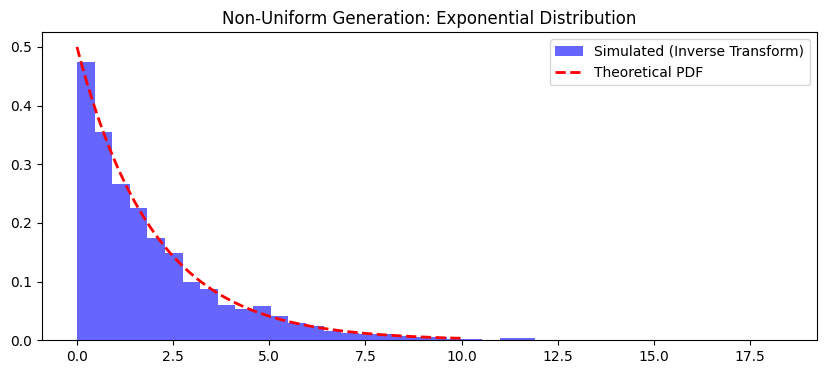

In [7]:
# Inverse Transform Sampling for Exponential Distribution
def generate_exponential(lam, size=5000):
    u = np.random.uniform(0, 1, size)
    # Inverse CDF of Exponential: x = -ln(1-u) / lambda
    return -np.log(1 - u) / lam

lam = 0.5  # Rate parameter
data_exp = generate_exponential(lam)

plt.figure(figsize=(10, 4))
plt.hist(data_exp, bins=40, density=True, color='blue', alpha=0.6, label='Simulated (Inverse Transform)')

# Theoretical Line
x_theory = np.linspace(0, 10, 100)
y_theory = lam * np.exp(-lam * x_theory)
plt.plot(x_theory, y_theory, 'r--', lw=2, label='Theoretical PDF')

plt.title('Non-Uniform Generation: Exponential Distribution')
plt.legend()
plt.show()